In [1]:
!pip install pm4py
import pm4py

   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 22.2 MB/s  0:00:00
   ---------------------------------------- 0.0/13.6 MB ? eta -:--:--
   ------------ --------------------------- 4.2/13.6 MB 58.2 MB/s eta 0:00:01
   ------------ --------------------------- 4.2/13.6 MB 58.2 MB/s eta 0:00:01
   ------------ --------------------------- 4.2/13.6 MB 58.2 MB/s eta 0:00:01
   ------------------------------ --------- 10.5/13.6 MB 12.6 MB/s eta 0:00:01
   ----------------------------------- ---- 12.1/13.6 MB 11.4 MB/s eta 0:00:01
   ---------------------------------------- 13.6/13.6 MB 12.2 MB/s  0:00:01
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 4.0/4.0 MB 45.4 MB/s  0:00:00

   ---------------------------------------- 0/4 [lxml]
   -------------------- ------------------- 2/4 [cvxopt]
   -------------------- ------------------- 2/4 [cvxopt]
   ---

In [2]:
import pandas as pd

df = pd.read_csv('events.csv')
df.head(5)

,id,user_id,sequence_number,session_id,created_at,ip_address,city,state,postal_code,browser,traffic_source,uri,event_type
0,2198523,NaN,3,83889ed2-2adc-4b9a-af5d-154f6998e778,2021-06-17 17:30:00+00:00,138.143.9.202,São Paulo,São Paulo,02675-031,Chrome,Adwords,/cancel,cancel
1,1773216,NaN,3,7a3fc3f2-e84f-44fe-8876-eff76741f7a3,2020-08-07 08:41:00+00:00,85.114.141.79,Santa Isabel,São Paulo,07500-000,Safari,Adwords,/cancel,cancel
2,2380515,NaN,3,13d9b2fb-eee1-43fd-965c-267b38dd7125,2021-02-15 18:48:00+00:00,169.250.255.132,Mairiporã,São Paulo,07600-000,IE,Adwords,/cancel,cancel
3,2250597,NaN,3,96f1d44e-9621-463c-954c-d8deb7fffe7f,2022-03-30 10:56:00+00:00,137.25.222.160,Cajamar,São Paulo,07750-000,Chrome,Adwords,/cancel,cancel
4,1834446,NaN,3,d09dce10-a7cb-47d3-a9af-44975566fa03,2019-09-05 01:18:00+00:00,161.114.4.174,São Paulo,São Paulo,09581-680,Chrome,Email,/cancel,cancel


In [3]:
df.shape

(2431963, 13)

In [4]:
data = df.copy()
data = data.rename(columns={'user_id': 'case:user_id'})
data = pm4py.format_dataframe(data, case_id='session_id', activity_key='event_type', timestamp_key='created_at')

In [5]:
event_log = pm4py.convert_to_event_log(data)

In [ ]:
#số lượng start_activity, end_activity, activities, variants của event_log
dfg, sa, ea = pm4py.discover_dfg(event_log)
activities_count = pm4py.get_event_attribute_values(event_log, "concept:name")
variants = pm4py.get_variants(event_log)
total_cases = len(event_log)
print(sa)
print(ea)
print(activities_count)
print("total case", total_cases)
print("number of variants",len(variants))

{'department': 339610, 'home': 87458, 'product': 252512, 'cart': 2145, 'cancel': 34}
{'cart': 125065, 'purchase': 181480, 'product': 249671, 'cancel': 123440, 'department': 2103}
{'department': 595323, 'product': 845607, 'cart': 595994, 'home': 87712, 'purchase': 181759, 'cancel': 125568}
total case 681759
number of variants 77


In [ ]:
# tính tỷ lệ từng variant
for variant, case_list in sorted(variants.items(), key=lambda x: len(x[1]), reverse=True):
    count = len(case_list)
    print(variant, count, round(count / total_cases, 4))

('product',) 124716 0.1829
('department', 'product') 122840 0.1802
('product', 'cart', 'cancel') 121371 0.178
('department', 'product', 'cart') 120692 0.177
('home', 'department', 'product', 'cart', 'purchase') 86760 0.1273
('department', 'product', 'cart', 'department', 'product', 'cart', 'purchase') 48985 0.0719
('department', 'product', 'cart', 'department', 'product', 'cart', 'department', 'product', 'cart', 'department', 'product', 'cart', 'purchase') 24703 0.0362
('department', 'product', 'cart', 'department', 'product', 'cart', 'department', 'product', 'cart', 'purchase') 18373 0.0269
('cart', 'product', 'cancel') 2069 0.003
('product', 'cancel', 'cart') 2066 0.003
('product', 'department') 2057 0.003
('department', 'cart', 'product') 2048 0.003
('product', 'department', 'cart') 2011 0.0029
('department', 'home', 'product', 'cart', 'purchase') 252 0.0004
('home', 'department', 'cart', 'product', 'purchase') 236 0.0003
('home', 'product', 'department', 'cart', 'purchase') 232 0.0

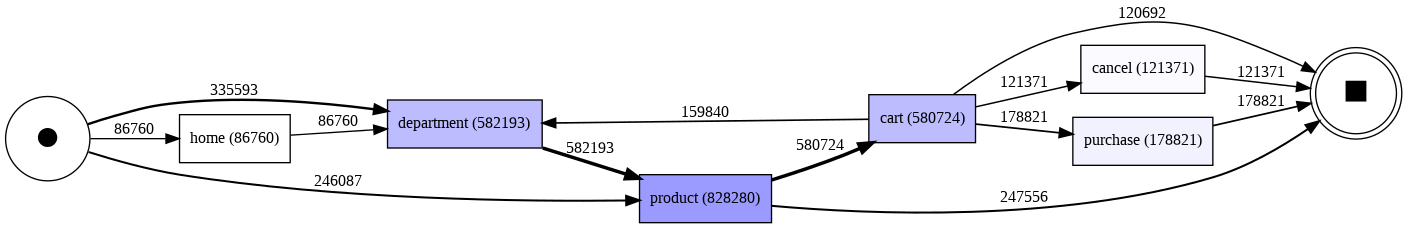

In [ ]:
k = 8
filtered_log_top = pm4py.filter_variants_top_k(event_log, k)
dfg_filter, sa_filter, ea_filter = pm4py.discover_dfg(filtered_log_top)
pm4py.view_dfg(dfg_filter, sa_filter, ea_filter)

In [ ]:
#sau khi chỉ giữ lại các variants phổ biến (top 8 variants)
activities_count_filter = pm4py.get_event_attribute_values(filtered_log_top, "concept:name")
variants_filter = pm4py.get_variants(filtered_log_top)
print(sa_filter)
print(ea_filter)
print(activities_count_filter)
print("total case", len(filtered_log_top))

{'department': 335593, 'home': 86760, 'product': 246087}
{'cart': 120692, 'purchase': 178821, 'product': 247556, 'cancel': 121371}
{'department': 582193, 'product': 828280, 'cart': 580724, 'home': 86760, 'purchase': 178821, 'cancel': 121371}
total case 668440


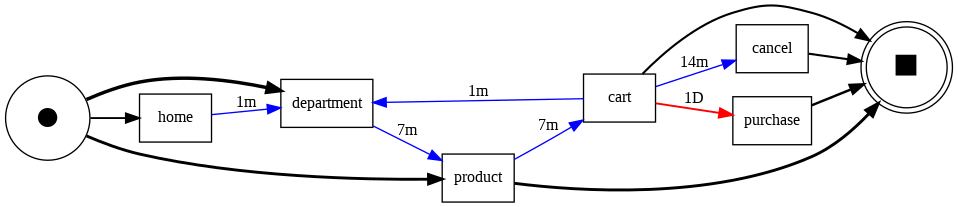

In [ ]:
performance_dfg, start_activities, end_activities = pm4py.discover_performance_dfg(filtered_log_top)
pm4py.view_performance_dfg(performance_dfg, start_activities, end_activities)

In [ ]:
case_cancel = pm4py.filter_event_attribute_values(event_log, "event_type", ["cancel"], level="case", retain=True)
case_purchase = pm4py.filter_event_attribute_values(event_log, "event_type", ["purchase"], level="case", retain=True)
print("số lượng case có event là cancel =", len(case_cancel), "(",round(len(case_cancel)/len(event_log),3),")")
print("số lượng case có event là purchase =", len(case_purchase), "(",round(len(case_purchase)/len(event_log),3),")")


số lượng case có event là cancel = 125568 ( 0.184 )
số lượng case có event là purchase = 181759 ( 0.267 )


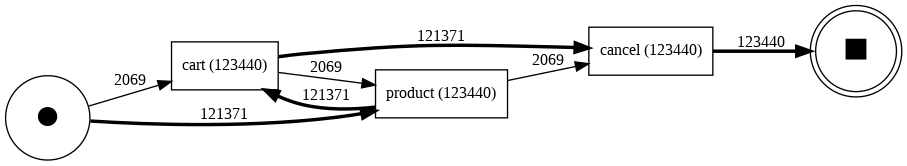

In [ ]:
case_end_cancel = pm4py.filter_end_activities(event_log, ["cancel"])
dfg_end, sa_end, ea_end = pm4py.discover_dfg(case_end_cancel)
pm4py.view_dfg(dfg_end, sa_end, ea_end)

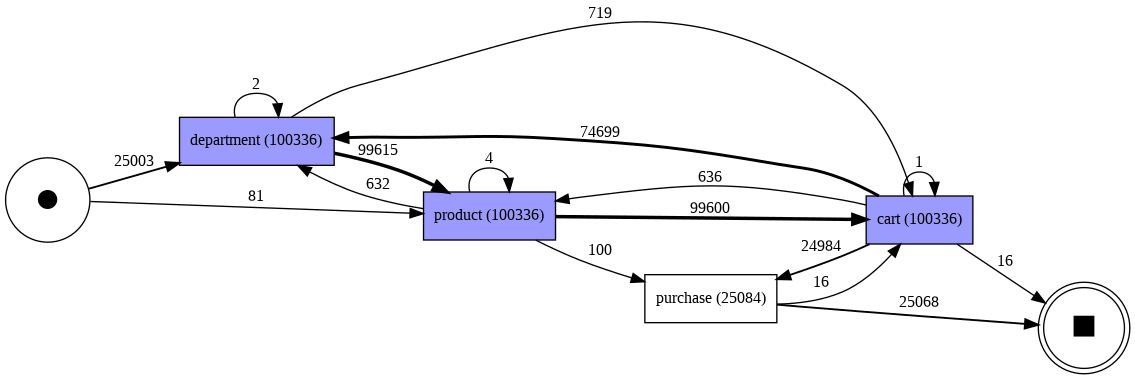

số lượng case có event 'product' lặp lại ít nhất 4 lần = 25084
tỷ lệ = 0.037


In [ ]:
event_rework = pm4py.filter_activities_rework(event_log, "product", 4)
dfg_rework, sa_rework, ea_rework = pm4py.discover_dfg(event_rework)
pm4py.view_dfg(dfg_rework, sa_rework, ea_rework)
print("số lượng case có event 'product' lặp lại ít nhất 4 lần =",len(event_rework))
print("tỷ lệ =", round(len(event_rework)/len(event_log),3))
#những case xem nhiều sản phẩm có lượt purchase cao

In [ ]:
#between = pm4py.filter_between(event_log, "product",)
#rework = pm4py.filter_activities_rework(event_log, "cart", 2)
start_home = pm4py.filter_start_activities(event_log,["home"])
start_dep = pm4py.filter_start_activities(event_log,["department"])
start_pro = pm4py.filter_start_activities(event_log,["product"])
start_cart = pm4py.filter_start_activities(event_log,["cart"])

pur_home = pm4py.filter_end_activities(start_home, ["purchase"])
pur_dep = pm4py.filter_end_activities(start_dep, ["purchase"])
pur_product = pm4py.filter_end_activities(start_pro, ["purchase"])

can_home = pm4py.filter_end_activities(start_home, ["cancel"])
can_dep = pm4py.filter_end_activities(start_dep, ["cancel"])
can_pro = pm4py.filter_end_activities(start_pro, ["cancel"])
can_cart = pm4py.filter_end_activities(start_cart, ["cancel"])
can_pro_end = pm4py.filter_end_activities(start_pro, ["product"])

print("home -> purchase:",len(pur_home))
print("department -> purchase:",len(pur_dep))
print("product -> purchase:",len(pur_product))
print("\nhome -> cancel:", len(can_home))
print("department -> cancel:", len(can_dep))
print("product -> cancel:", len(can_pro))
print("cart -> cancel:", len(can_cart))
print("product -> end:", len(can_pro_end))

home -> purchase: 87189
department -> purchase: 93533
product -> purchase: 284

home -> cancel: 0
department -> cancel: 0
product -> cancel: 120069
cart -> cancel: 2251
product -> end: 125288
